# Prueba 1 - YOLOv8 XS con KerasCV para xView Detection

Este notebook recoge la primera aproximacion al problema de deteccion de objetos sobre el conjunto xView Detection. El objetivo es entrenar un detector de una etapa basado en YOLOv8 XS, inicializado con pesos preentrenados en COCO y adaptado a las cuatro clases de la practica: Small car, Bus, Truck y Building. La prueba funciona como linea base para comparar iteraciones posteriores con umbrales, arquitecturas y estrategias de entrenamiento mas ajustadas.

El cuaderno comienza comprobando la disponibilidad de GPU, define las clases y las estructuras auxiliares para imagenes y anotaciones, localiza el dataset tanto en entorno local como en Kaggle, carga el fichero de anotaciones y realiza una division entrenamiento-validacion de 6845 y 761 imagenes. A continuacion construye el pipeline de datos con TensorFlow/KerasCV, aplica aumentos de imagen, entrena el detector con SGD y guarda el mejor conjunto de pesos segun la perdida de validacion.

La parte final evalua el modelo sobre validacion mediante precision, recall, AP por clase, matriz de confusion y mAP. Despues ejecuta la inferencia sobre 852 imagenes de test y genera el fichero de entrega con `prediction.json` comprimido en `submission.zip`. El resultado de referencia de esta primera prueba es un mejor modelo en la epoca 36, con `val_loss = 2.5125` y `mAP = 17.553%`; estos resultados motivan los ajustes de la segunda prueba.


In [5]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [7]:
categories = {0: 'Small car', 1: 'Bus', 2: 'Truck', 3: 'Building'}

In [8]:
from pathlib import Path
import warnings
import rasterio
import numpy as np

LOCAL_DATA_ROOT = Path('../PROJECT/xview_detection')
KAGGLE_INPUT_DIR = Path('/kaggle/input')

json_candidates = []
if KAGGLE_INPUT_DIR.exists():
    json_candidates = sorted(KAGGLE_INPUT_DIR.rglob('xview_det_train.json'))
    if not json_candidates:
        json_candidates = sorted(KAGGLE_INPUT_DIR.rglob('xview_ann_train.json'))

if json_candidates:
    JSON_FILE = json_candidates[0]
    DATA_ROOT = JSON_FILE.parent
else:
    DATA_ROOT = LOCAL_DATA_ROOT
    JSON_FILE = DATA_ROOT / 'xview_det_train.json'

TRAIN_DIR = DATA_ROOT / 'xview_train'
TEST_DIR = DATA_ROOT / 'xview_test'
WORKDIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')

print('DATA_ROOT:', DATA_ROOT)
print('JSON_FILE:', JSON_FILE)
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    filepath = DATA_ROOT / filename
    if not filepath.exists():
        raise FileNotFoundError(f'No se encontro la imagen: {filepath}')

    src_raster = rasterio.open(filepath, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    src_raster.close()
    return img

DATA_ROOT: /kaggle/input/datasets/victordmv/visu-detect
JSON_FILE: /kaggle/input/datasets/victordmv/visu-detect/xview_det_train.json
TRAIN_DIR exists: True
TEST_DIR exists: True


#### Entrenamiento

Se prepara el pipeline de entrenamiento para adaptar YOLOv8 XS al conjunto xView Detection.


In [9]:
import json

# Load database
if not JSON_FILE.exists():
    raise FileNotFoundError(f'No se encontro el JSON de entrenamiento: {JSON_FILE}')

with open(JSON_FILE) as ifs:
    json_data = json.load(ifs)

In [10]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img in json_data['images'].values():
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    for json_ann in [elem for elem in json_data['annotations'].values() if elem['image_id'] == json_img['image_id']]:
        obj = GenericObject()
        obj.id = json_ann['image_id']
        obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
        obj.category = json_ann['category_id']
        counts[obj.category] += 1
        image.add_object(obj)
    anns.append(image)
print(counts)

{'Small car': 188300, 'Bus': 6269, 'Truck': 10600, 'Building': 275943}


In [11]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.1, random_state=1, shuffle=True)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 6845
Number of validation images: 761


In [12]:
# Load architecture
import keras_cv

print('Load model')
prediction_decoder = keras_cv.layers.NonMaxSuppression(bounding_box_format='xyxy', from_logits=False, confidence_threshold=0.2, iou_threshold=0.7)
model = keras_cv.models.YOLOV8Detector.from_preset(preset='yolo_v8_xs_backbone_coco', num_classes=len(categories), load_weights=True, bounding_box_format='xyxy', prediction_decoder=prediction_decoder)
model.summary()

Load model


I0000 00:00:1780104560.466405      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780104560.472415      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "yolov8_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, None,     │  1,277,680 │ input_layer_1[0]… │
│ (Functional)        │ None, 64), (None, │            │                   │
│                     │ None, None, 128), │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat (Repeat)     │ (None, None,      │          0 │ functional[0][2]  │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_1 (Repeat)   │ (None, None,      │          0 │ repeat[0][0]      │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None,      │          0 │ repeat_1[0][0],   │
│ (Concatenate)       │ None, 384)        │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_co… │ (None, None,      │     49,152 │ concatenate_5[0]… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_bn  │ (None, None,      │        512 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre     │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_4 (Split)     │ [(None, None,     │          0 │ pa_fpn_p4p5_pre[… │
│                     │ None, 64), (None, │            │                   │
│                     │ None, None, 64)]  │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ split_4[0][1]     │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │     36,864 │ pa_fpn_p4p5_pre_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │        256 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_1 │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │     36,864 │ pa_fpn_p4p5_pre_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,536,316 (13.49 MB)

 Trainable params: 3,524,764 (13.45 MB)

 Non-trainable params: 11,552 (45.12 KB)

In [13]:
from tensorflow.keras.optimizers import SGD

# Learning rate is changed to 0.001
opt = SGD(learning_rate=1e-3, momentum=0.9, global_clipnorm=10.0)
model.compile(optimizer=opt, classification_loss='binary_crossentropy', box_loss='ciou', jit_compile=False)

In [14]:
from pathlib import Path
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Best-weights checkpoint, saved in Kaggle's persistent working directory.
WORKDIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
MODEL_PATH = WORKDIR / 'detector_best.weights.h5'
RESUME_TRAINING = True

if RESUME_TRAINING and MODEL_PATH.exists():
    print('Loading checkpoint from:', MODEL_PATH)
    model.load_weights(str(MODEL_PATH))
else:
    print('No previous checkpoint found. Training will start from the current model weights.')

# Callbacks
model_checkpoint = ModelCheckpoint(
    filepath=str(MODEL_PATH),
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,
)
reduce_lr = ReduceLROnPlateau('val_loss', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_loss', patience=40, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, reduce_lr, early_stop, terminate]

print('Best model weights will be saved in:', MODEL_PATH)

No previous checkpoint found. Training will start from the current model weights.
Best model weights will be saved in: /kaggle/working/detector_best.weights.h5


In [15]:
def image_generator(filename, tile, bboxes, categories):
    def load_sample(filepath):
        image = load_geoimage(filepath.numpy().decode('utf-8'))
        return tf.cast(image, tf.uint8)
    # Load image
    img = tf.squeeze(tf.py_function(func=load_sample, inp=[filename], Tout=[tf.uint8]), axis=0)  # tf.print(tf.shape(img)) -> [H, W, 3]
    img_roi = tf.image.pad_to_bounding_box(img, 0, 0, 640, 640)
    return {'images': tf.cast(img_roi, tf.float32), 'bounding_boxes': {'boxes': bboxes, 'classes': categories}}

def ragged_to_dense(inputs):
    from keras_cv import bounding_box
    return {'images': inputs['images'].to_tensor(), 'bounding_boxes': bounding_box.to_dense(inputs['bounding_boxes'], max_boxes=2000)}

def dict_to_tuple(inputs):
    return inputs['images'], inputs['bounding_boxes']

In [16]:
# Generate the list of objects from annotations
filenames_train, tiles_train, bboxes_train, categories_train = zip(*list(map(lambda img_ann: (img_ann.filename, list(img_ann.tile), list([list(obj_ann.bb) for obj_ann in img_ann.objects]), list([list(categories.keys())[list(categories.values()).index(obj_ann.category)] for obj_ann in img_ann.objects])), anns_train)))
filenames_valid, tiles_valid, bboxes_valid, categories_valid = zip(*list(map(lambda img_ann: (img_ann.filename, list(img_ann.tile), list([list(obj_ann.bb) for obj_ann in img_ann.objects]), list([list(categories.keys())[list(categories.values()).index(obj_ann.category)] for obj_ann in img_ann.objects])), anns_valid)))
ds_train = tf.data.Dataset.from_tensor_slices((tf.cast(filenames_train, tf.string), tf.cast(tiles_train, tf.int32), tf.cast(tf.ragged.constant(bboxes_train), tf.float32).to_tensor(), tf.cast(tf.ragged.constant(categories_train), tf.float32).to_tensor()))
ds_valid = tf.data.Dataset.from_tensor_slices((tf.cast(filenames_valid, tf.string), tf.cast(tiles_valid, tf.int32), tf.cast(tf.ragged.constant(bboxes_valid), tf.float32).to_tensor(), tf.cast(tf.ragged.constant(categories_valid), tf.float32).to_tensor()))
ds_train = ds_train.map(image_generator, num_parallel_calls=tf.data.AUTOTUNE)
ds_valid = ds_valid.map(image_generator, num_parallel_calls=tf.data.AUTOTUNE)
# Generators
batch_size = 4
ds_train = ds_train.shuffle(batch_size*5)
ds_train = ds_train.ragged_batch(batch_size=batch_size, drop_remainder=True)
ds_valid = ds_valid.ragged_batch(batch_size=batch_size, drop_remainder=True)
data_augmentation = tf.keras.Sequential(
    layers=[keras_cv.layers.RandomFlip(mode='horizontal_and_vertical', bounding_box_format='xyxy'),
            keras_cv.layers.RandomShear(x_factor=0.2, y_factor=0.2, bounding_box_format='xyxy'),
            keras_cv.layers.RandomColorDegeneration(factor=0.5)])
ds_train = ds_train.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
# Bounding box tensors need to be Dense instead of Ragged
ds_train = ds_train.map(ragged_to_dense, num_parallel_calls=tf.data.AUTOTUNE)
ds_valid = ds_valid.map(ragged_to_dense, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
ds_valid = ds_valid.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

In [17]:
import numpy as np

print('Training model')
epochs = 40
train_steps, valid_steps = len(ds_train), len(ds_valid)
h = model.fit(ds_train, steps_per_epoch=train_steps, validation_data=ds_valid, validation_steps=valid_steps, epochs=epochs, callbacks=callbacks, verbose=1)
# Best validation model
best_idx = int(np.argmin(h.history['val_loss']))
best_value = np.min(h.history['val_loss'])
print('Best validation model: epoch ' + str(best_idx+1), ' - val_loss ' + str(best_value))

Training model
Epoch 1/40


I0000 00:00:1780104648.998969     138 service.cc:152] XLA service 0x7c5ae59c67a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780104648.999014     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780104648.999019     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780104649.081093     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780104651.343711     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1711/1711 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - box_loss: 3.2051 - class_loss: 10.9350 - loss: 14.1402
Epoch 1: val_loss improved from None to 2.95751, saving model to /kaggle/working/detector_best.weights.h5

Epoch 1: finished saving model to /kaggle/working/detector_best.weights.h5
1711/1711 ━━━━━━━━━━━━━━━━━━━━ 827s 461ms/step - box_loss: 2.7182 - class_loss: 3.1865 - loss: 5.9047 - val_box_loss: 2.4719 - val_class_loss: 0.4856 - val_loss: 2.9575 - learning_rate: 0.0010
Epoch 2/40
1711/1711 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - box_loss: 2.3516 - class_loss: 0.5038 - loss: 2.8553
Epoch 2: val_loss improved from 2.95751 to 2.80314, saving model to /kaggle/working/detector_best.weights.h5

Epoch 2: finished saving model to /kaggle/working/detector_best.weights.h5
1711/1711 ━━━━━━━━━━━━━━━━━━━━ 790s 461ms/step - box_loss: 2.3266 - class_loss: 0.4892 - loss: 2.8158 - val_box_loss: 2.3705 - val_class_loss: 0.4326 - val_loss: 2.8031 - learning_rate: 0.0010
Epoch 3/40
1711/1711 ━━━━━━━━━━━━━

#### Validacion

Se calculan metricas de deteccion sobre el subconjunto de validacion para estimar precision, recall, AP por clase y mAP.


In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as col
import numpy as np
%matplotlib inline

def area_intersection(boxes, box):
    xmin = np.maximum(np.min(boxes[:, 0::2], axis=1), np.min(box[0::2]))
    ymin = np.maximum(np.min(boxes[:, 1::2], axis=1), np.min(box[1::2]))
    xmax = np.minimum(np.max(boxes[:, 0::2], axis=1), np.max(box[0::2]))
    ymax = np.minimum(np.max(boxes[:, 1::2], axis=1), np.max(box[1::2]))
    w = np.maximum(xmax - xmin + 1.0, 0.0)
    h = np.maximum(ymax - ymin + 1.0, 0.0)
    return w * h

def area_union(boxes, box):
    area_anns = (np.max(box[0::2])-np.min(box[0::2])+1.0) * (np.max(box[1::2])-np.min(box[1::2])+1.0)
    area_pred = (np.max(boxes[:, 0::2], axis=1)-np.min(boxes[:, 0::2], axis=1)+1.0) * (np.max(boxes[:, 1::2], axis=1)-np.min(boxes[:, 1::2], axis=1)+1.0)
    return area_anns + area_pred - area_intersection(boxes, box)

def calc_iou(boxes, box):
    iou = area_intersection(boxes, box) / area_union(boxes, box)
    max_value = np.max(iou)
    max_index = np.argmax(iou)
    return max_value, max_index

def calc_ap(rec, prec):
    # First append sentinel values at the end
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    # Compute the precision envelope
    for i in range(mpre.size-1, 0, -1):
        mpre[i-1] = np.maximum(mpre[i-1], mpre[i])
    # To calculate area under PR curve, look for points where X axis (recall) changes value
    i = np.where(mrec[1:] != mrec[:-1])[0]
    # and sum (\Delta recall) * prec
    ap = np.sum((mrec[i+1] - mrec[i]) * mpre[i+1])
    return ap

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=categories, yticklabels=categories, ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

def draw_precision_recall(precisions, recalls, categories):
    # Draw precision-recall curves for each category
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    plt.axis([0, 1, 0, 1])
    c_dark = list(filter(lambda x: x.startswith('dark'), col.cnames.keys()))
    aps = []
    # Compare categories for a specific algorithm
    for idx in range(len(categories)):
        plt.plot(recalls[idx], precisions[idx], color=c_dark[idx], label=categories[idx], linewidth=4.0)
        aps.append(calc_ap(recalls[idx], precisions[idx]))
    handles, labels = ax.get_legend_handles_labels()
    labels = [str(val + ' [' + "{:.3f}".format(aps[idx]) + ']') for idx, val in enumerate(labels)]
    handles = [h for (ap, h) in sorted(zip(aps, handles), key=lambda x: x[0], reverse=True)]
    labels = [l for (ap, l) in sorted(zip(aps, labels), key=lambda x: x[0], reverse=True)]
    leg = plt.legend(handles, labels, loc='upper right')
    leg.set_zorder(100)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid("on", linestyle="--", linewidth=2.0)
    fig.tight_layout()
    plt.show()

In [19]:
import numpy as np
from tqdm import tqdm

model.load_weights(str(MODEL_PATH))
# Generate the list of objects from annotations
ds_valid = tf.data.Dataset.from_tensor_slices((tf.cast(filenames_valid, tf.string), tf.cast(tiles_valid, tf.int32), tf.cast(tf.ragged.constant(bboxes_valid), tf.float32).to_tensor(), tf.cast(tf.ragged.constant(categories_valid), tf.float32).to_tensor()))
ds_valid = ds_valid.map(image_generator, num_parallel_calls=tf.data.AUTOTUNE).cache()
ds_valid = ds_valid.batch(batch_size=1)
ds_valid = ds_valid.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
# Process each tile sequentially
iterator = iter(ds_valid)
annotations, predictions = {}, {}
for ann in tqdm(anns_valid):
    # Save annotations
    annotations.setdefault(ann.filename, {})
    predictions.setdefault(ann.filename, {})
    for obj in ann.objects:
        annotations[ann.filename].setdefault(obj.category, {'bbox': []})
        annotations[ann.filename][obj.category]['bbox'].append(obj.bb)
    # Save prediction
    image, _ = next(iterator)
    y_pred = model.predict(image, verbose=0)
    for i in range(np.squeeze(y_pred['num_detections'])):
        obj = GenericObject()
        bbox = np.squeeze(y_pred['boxes'])[i]
        obj.bb = (bbox[0], bbox[1], bbox[2], bbox[3])
        obj.category = categories[np.squeeze(y_pred['classes'])[i]]
        obj.score = np.squeeze(y_pred['confidence'])[i]
        predictions[ann.filename].setdefault(obj.category, {'bbox': [], 'confidence': []})
        predictions[ann.filename][obj.category]['bbox'].append(obj.bb)
        predictions[ann.filename][obj.category]['confidence'].append(obj.score)  # sort detections by confidence

100%|██████████| 761/761 [02:06<00:00,  6.01it/s]


In [20]:
threshold = 0.5
default_cls = 'BACKGROUND'
y_true, y_pred = [], []  # confusion matrix
tps, confidences = dict(), dict()  # draw precision-recall curves for each category
for cls in categories.values():
    # Compute TP, FP and FN for each image
    tps[cls], confidences[cls] = [], []
    for f in predictions:
        # Sort 'cls' predictions by confidence for each file
        pred_boxes, pred_confidences = [], []
        if cls in predictions[f].keys():
            for idx in range(len(predictions[f][cls]['bbox'])):
                pred_boxes.append(predictions[f][cls]['bbox'][idx])
                pred_confidences.append(predictions[f][cls]['confidence'][idx])
            sorted_ind = np.argsort(-np.array(pred_confidences))
            pred_boxes = np.array(pred_boxes)[sorted_ind, :]
        pred_boxes = np.array(pred_boxes).astype(float)
        # Define 'cls' annotations for each file
        anno_boxes = []
        if cls in annotations[f].keys():
            anno_boxes = annotations[f][cls]['bbox']
        anno_boxes = np.array(anno_boxes).astype(float)
        # Define horizontal or oriented bounding boxes
        anno_indices = list(range(len(anno_boxes)))
        # Compare a single prediction 'pred_box' with all annotations 'anno_boxes'
        for pred_idx, pred_box in enumerate(pred_boxes):
            # A prediction is correct if its IoU with the ground truth is above the threshold
            iou_value, ann_index = calc_iou(anno_boxes, pred_box) if len(anno_boxes) > 0 else (-1, -1)
            if iou_value > threshold and ann_index in anno_indices:
                # TP
                anno_indices.remove(int(ann_index))
                tps[cls] += [1.0]
                y_true += [cls]
            else:
                # FP
                tps[cls] += [0.0]
                y_true += [default_cls]
            y_pred += [cls]
            confidences[cls] += [pred_confidences[pred_idx]]
        # FN
        y_true += [cls] * len(anno_indices)
        y_pred += [default_cls] * len(anno_indices)
y_true, y_pred = np.array(y_true), np.array(y_pred)

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

# Compute AP metric
precision_list, recall_list, ap_list = [], [], []
for cls in categories.values():
    sorted_ind = np.argsort(-np.array(confidences[cls]))
    tp = np.cumsum(np.array(tps[cls])[sorted_ind], dtype=float)
    recall = np.array([0.0]) if len(tp) == 0 else tp / np.maximum(np.sum(y_true == cls), np.finfo(np.float64).eps)
    precision = np.array([0.0]) if len(tp) == 0 else tp / np.maximum(list(range(1, np.sum(y_pred == cls)+1)), np.finfo(np.float64).eps)
    ap = calc_ap(recall, precision)
    print('> %s: Recall: %.3f%% Precision: %.3f%% AP: %.3f%%' % (cls, recall[-1]*100, precision[-1]*100, ap*100))
    precision_list.append(precision)
    recall_list.append(recall)
    ap_list.append(ap)
mean_ap = np.mean(ap_list)
print('mAccuracy: %.3f%%' % (accuracy_score(y_true, y_pred)*100))
print('mRecall: %.3f%%' % (recall_score(y_true, y_pred, average='macro', zero_division=1)*100))
print('mPrecision: %.3f%%' % (precision_score(y_true, y_pred, average='macro', zero_division=1)*100))
print('mAP: %.3f%%' % (mean_ap*100))

> Small car: Recall: 39.015% Precision: 46.468% AP: 26.946%
> Bus: Recall: 8.281% Precision: 28.042% AP: 3.078%
> Truck: Recall: 0.287% Precision: 37.500% AP: 0.123%
> Building: Recall: 48.414% Precision: 59.603% AP: 40.064%
mAccuracy: 31.817%
mRecall: 19.199%
mPrecision: 34.323%
mAP: 17.553%


Confusion matrix:
[[    0  7866   136     5  9423]
 [10673  6828     0     0     0]
 [  587     0    53     0     0]
 [ 1041     0     0     3     0]
 [14814     0     0     0 13903]]


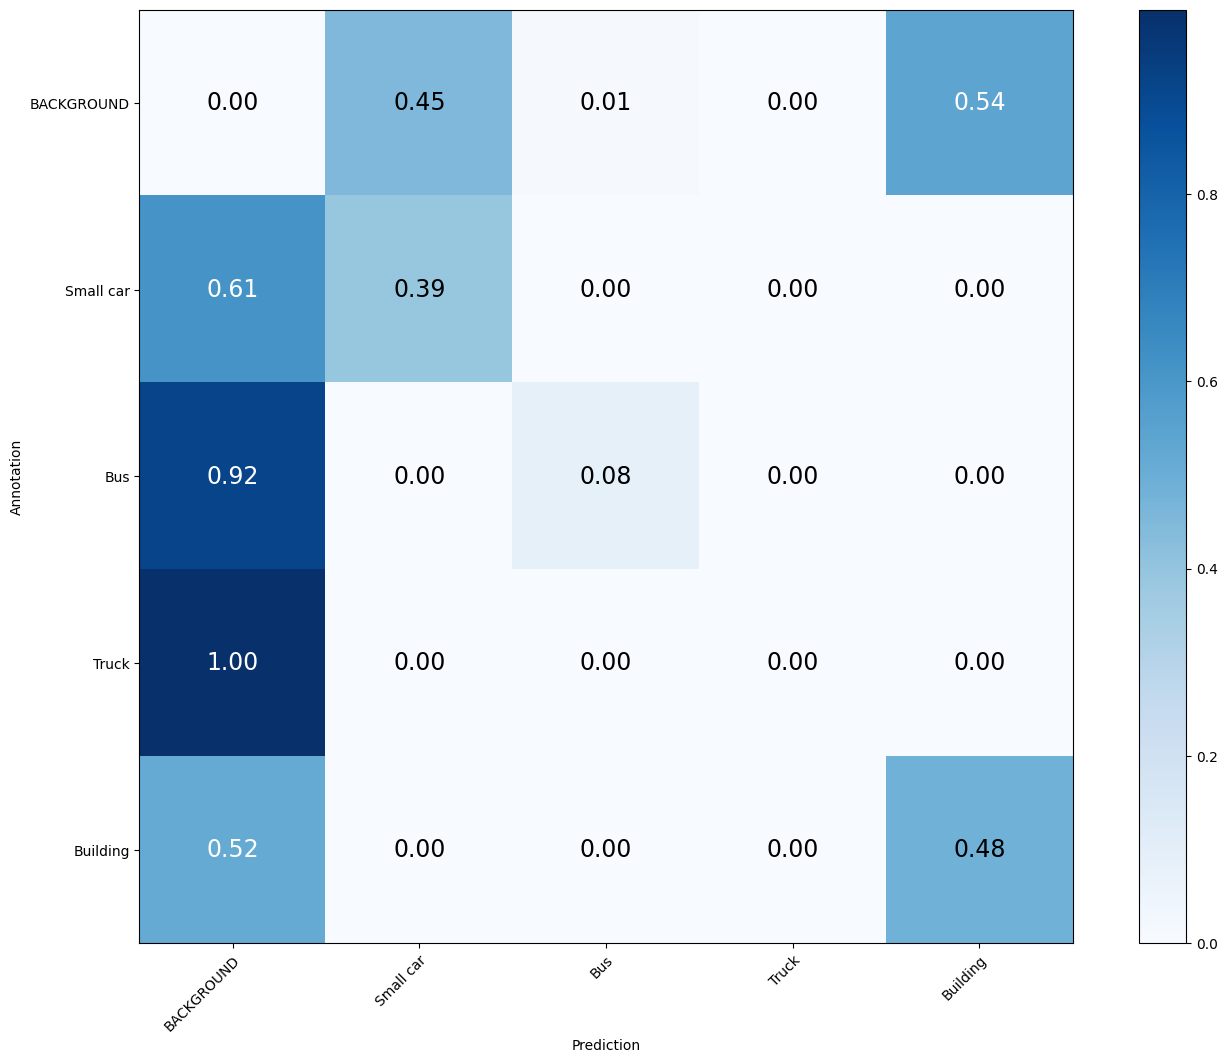

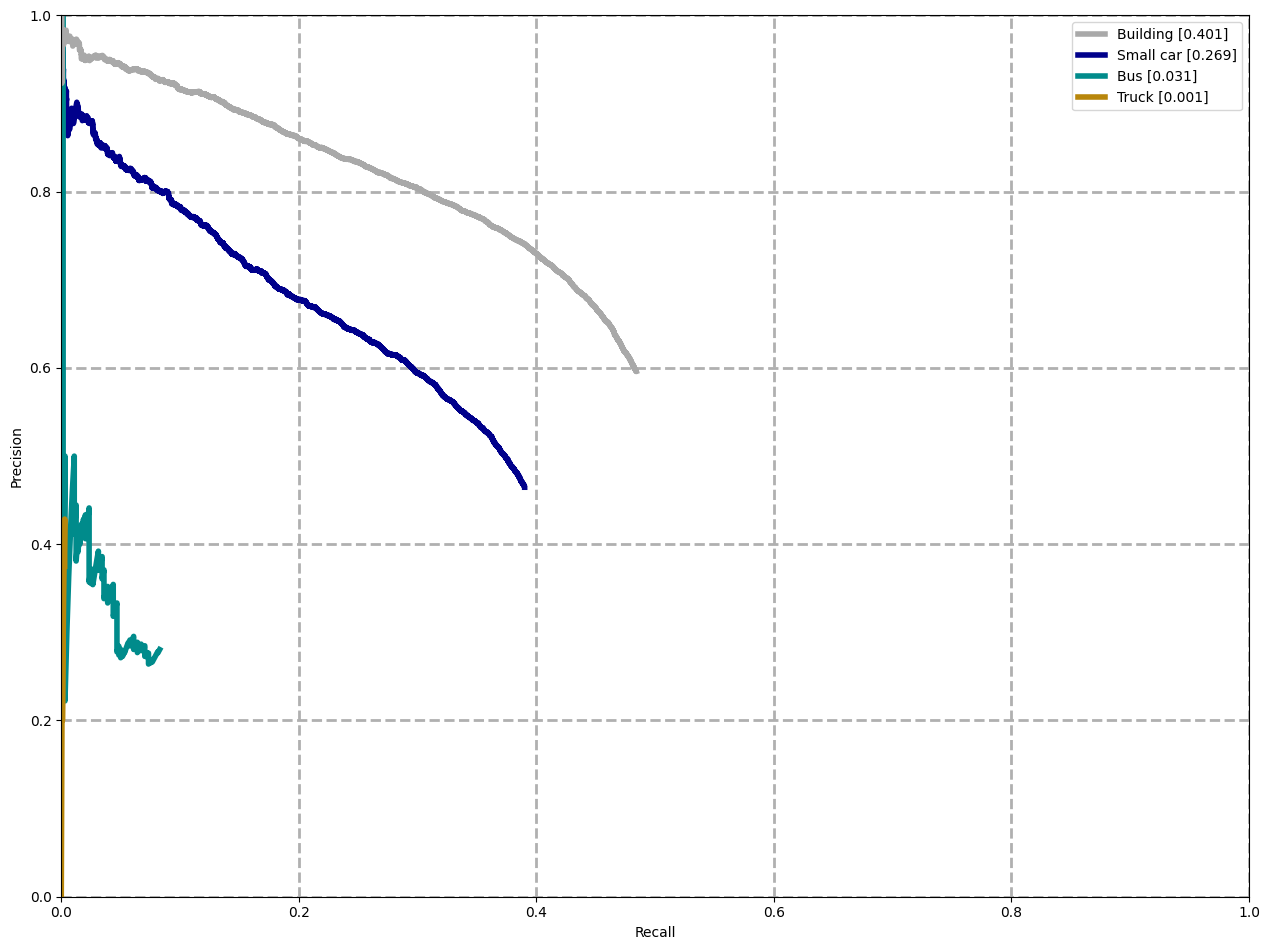

In [22]:
names = list(categories.values()).copy()
names.insert(0, default_cls)
cm = confusion_matrix(y_true, y_pred, labels=names)
print('Confusion matrix:')
print(cm)
draw_confusion_matrix(cm, names)
draw_precision_recall(precision_list, recall_list, categories)

#### Prueba sobre test y fichero de entrega

Se ejecuta la inferencia sobre las imagenes de test y se genera el ZIP con el `prediction.json` requerido.


In [23]:
import numpy as np

anns = []
if not TEST_DIR.exists():
    raise FileNotFoundError(f'No se encontro la carpeta de test: {TEST_DIR}')

for path in sorted(TEST_DIR.rglob('*.tif')):
    image = GenericImage(path.relative_to(DATA_ROOT).as_posix())
    image.tile = np.array([0, 0, 640, 640])
    anns.append(image)

print('Number of testing images: ' + str(len(anns)))

Number of testing images: 852


In [24]:
import numpy as np
from tqdm import tqdm

model.load_weights(str(MODEL_PATH))
# Generate the list of objects from annotations
filenames_test, tiles_test, bboxes_test, categories_test = zip(*list(map(lambda img_ann: (img_ann.filename, list(img_ann.tile), list([list(obj_ann.bb) for obj_ann in img_ann.objects]), list([list(categories.keys())[list(categories.values()).index(obj_ann.category)] for obj_ann in img_ann.objects])), anns)))
ds_test = tf.data.Dataset.from_tensor_slices((tf.cast(filenames_test, tf.string), tf.cast(tiles_test, tf.int32), tf.cast(tf.ragged.constant(bboxes_test), tf.float32).to_tensor(), tf.cast(tf.ragged.constant(categories_test), tf.float32).to_tensor()))
ds_test = ds_test.map(image_generator, num_parallel_calls=tf.data.AUTOTUNE).cache()
ds_test = ds_test.batch(batch_size=1)
ds_test = ds_test.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
# Process each tile sequentially
iterator = iter(ds_test)
predictions = {}
for ann in tqdm(anns):
    # Generate prediction
    image, _ = next(iterator)
    y_pred = model.predict(image, verbose=0)
    predictions.setdefault(ann.filename, {})
    for i in range(np.squeeze(y_pred['num_detections'])):
        obj = GenericObject()
        bbox = np.squeeze(y_pred['boxes'])[i]
        obj.bb = (bbox[0], bbox[1], bbox[2], bbox[3])
        obj.category = categories[np.squeeze(y_pred['classes'])[i]]
        obj.score = np.squeeze(y_pred['confidence'])[i]
        predictions[ann.filename].setdefault(obj.category, {'bbox': [], 'confidence': []})
        predictions[ann.filename][obj.category]['bbox'].append(obj.bb)
        predictions[ann.filename][obj.category]['confidence'].append(obj.score)  # sort detections by confidence
# Save prediction
predictions_data = {"images": {}, "annotations": {}, "categories": {}}
predictions_data["categories"] = categories
imgs_idx, annos_idx = 0, 0
for pred in predictions:
    num_objects = 0
    for cat in predictions[pred]:
        for bb in predictions[pred][cat]['bbox']:
            num_objects += len(predictions[pred][cat]['bbox'])
    image_data = {"image_id": pred.split('/')[-1], "filename": pred, "num_objects": num_objects, "width": 640, "height": 640}
    predictions_data["images"][imgs_idx] = image_data
    imgs_idx += 1
    bboxes, confs = [], []
    for cat in predictions[pred]:
        for i in range(len(predictions[pred][cat]['bbox'])):  
            bbox = predictions[pred][cat]['bbox'][i]
            conf = predictions[pred][cat]['confidence'][i]
            annotation_data = {"image_id": pred.split('/')[-1], "category_id": cat, "bbox": (int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])), "confidence": str(conf)}
            predictions_data["annotations"][annos_idx] = annotation_data
            annos_idx += 1

100%|██████████| 852/852 [02:09<00:00,  6.57it/s]


In [25]:
import json
import zipfile
from IPython.display import FileLink, display

prediction_path = WORKDIR / 'prediction.json'
submission_path = WORKDIR / 'submission.zip'

with open(prediction_path, 'w') as outfile:
    json.dump(predictions_data, outfile)

with zipfile.ZipFile(submission_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(prediction_path, arcname='prediction.json')

print('Archivos generados:')
print(prediction_path, '-', prediction_path.stat().st_size, 'bytes')
print(submission_path, '-', submission_path.stat().st_size, 'bytes')
display(FileLink(str(submission_path)))

Archivos generados:
/kaggle/working/prediction.json - 7301599 bytes
/kaggle/working/submission.zip - 939325 bytes


/kaggle/working/submission.zip